# Annotation-budget effectiveness

How much labeled data reaches **80%, 90%, 95%, or 100%** of full-budget performance? Lower required budgets are better; compare each strategy with random sampling.

All query strategies using mean pooling are included; max-pooling runs are excluded. A **common reference** for each metric is the mean score of completed **100%-budget random-sampling, mean-pooling runs** (one run per seed). This makes absolute target scores identical across strategies; percentages are not relative to each strategy's own endpoint. The reference scores and seed count are shown below.

At each acquisition round, average scores and actual labeled-frame percentages across available seeds within identical configurations (excluding name and seed). Select each run's epoch by highest validation edit score, and take all three metrics from that same epoch, matching `performance.ipynb`. Exclude incomplete rounds. Seed counts can fall at later rounds while training continues; the coverage table makes this visible.

For target X, report the **smallest observed mean budget Y** whose mean score is at least X% of the reference. No interpolation, extrapolation, or monotonic smoothing is used: a first crossing does not guarantee later rounds stay above the target. `Not reached` means no completed observation reaches it. Budgets use actual labeled training frames, not nominal acquisition percentages. Results describe these validation runs, not a statistical guarantee of equivalent performance.

Re-run all cells to refresh as training progresses.

In [6]:
# If needed in this kernel: %pip install numpy pandas matplotlib nbformat ipykernel
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
pd.set_option("display.max_colwidth", 100)

# Works from the repository root, this notebook's directory, or a subdirectory.
relative_runs = Path("experiments/4_active_learning_runs")
RUNS_DIR = next(
    (base / relative_runs for base in [Path.cwd(), *Path.cwd().parents]
     if (base / relative_runs).is_dir()), None
)
if RUNS_DIR is None:
    raise FileNotFoundError("Run from inside the alpes repository or set RUNS_DIR explicitly.")
METRICS = {"val_edit": "Validation edit score", "val_f1_element": "Validation F1 element",
           "val_f1_event": "Validation F1 event"}
print(f"Loading runs from {RUNS_DIR}")

Loading runs from /mnt/ssd2/zachary/alpes/experiments/4_active_learning_runs


In [7]:
def read_json(path):
    with path.open() as stream:
        return json.load(stream)


records, inventory, skipped = [], [], []
settings_by_group = {}
for config_path in sorted(RUNS_DIR.glob("*/config.json")):
    config = read_json(config_path)
    if config.get("query_score_pooling", "").upper() != "MEAN":
        continue
    run_dir = config_path.parent
    assert config["active_learning_budget_unit"] == "percent_of_training_frames"
    total_frames = config["total_training_frames"]
    assert total_frames > 0
    settings = {k: v for k, v in config.items() if k not in {"name", "seed"}}
    group = json.dumps(settings, sort_keys=True)
    settings_by_group[group] = settings
    accepted = 0
    for round_dir in sorted(run_dir.glob("round_*")):
        loss_path, labeled_path = round_dir / "loss.json", round_dir / "labeled_train.json"
        reason = None
        if not loss_path.exists() or not labeled_path.exists():
            reason = "Missing loss or labeled-pool file"
        else:
            losses = pd.DataFrame(read_json(loss_path))
            expected_epochs = config["f3ed"]["num_epochs"]
            if "epoch" not in losses or not set(range(expected_epochs)).issubset(set(losses["epoch"])):
                reason = "Training incomplete"
            elif not set(METRICS).issubset(losses.columns):
                reason = "Missing validation metrics"
            else:
                evaluated = losses.loc[
                    losses["epoch"] >= config["f3ed"]["start_val_epoch"]
                ].dropna(subset=list(METRICS)).sort_values("epoch")
                if evaluated.empty:
                    reason = "No evaluated epoch"
        if reason:
            skipped.append({"run": run_dir.name, "round": round_dir.name, "reason": reason})
            continue
        best = evaluated.loc[evaluated["val_edit"].idxmax()]
        labeled_frames = sum(item["num_frames"] for item in read_json(labeled_path))
        assert 0 < labeled_frames <= total_frames
        assert np.isfinite(best[list(METRICS)].to_numpy(dtype=float)).all()
        records.append({"run": run_dir.name, "group": group, "seed": config["seed"],
                        "strategy": config["query_strategy"],
                        "round": int(round_dir.name.split("_")[-1]),
                        "labeled_frames": labeled_frames,
                        "budget_pct": 100 * labeled_frames / total_frames,
                        "best_epoch": int(best["epoch"]),
                        **{metric: float(best[metric]) for metric in METRICS}})
        accepted += 1
    inventory.append({"run": run_dir.name, "group": group, "seed": config["seed"],
                      "completed_rounds": accepted})

rounds = pd.DataFrame(records)
if rounds.empty:
    raise ValueError("No completed mean-pooling rounds found.")
# Keep labels readable, but distinguish any additional configurations of a strategy.
labels = {}
for group, settings in settings_by_group.items():
    strategy = settings["query_strategy"]
    label = strategy.replace("_MEASURE", "").replace("_", " ").title()
    if strategy == "RANDOM_SAMPLING":
        label = "Random sampling (baseline)"
    pooling = settings["query_score_pooling"].upper()
    label += f" ({pooling.lower()} pooling)"
    peers = [g for g, s in settings_by_group.items()
             if s["query_strategy"] == strategy and s["query_score_pooling"].upper() == pooling]
    if len(peers) > 1:
        label += f" [config {peers.index(group) + 1}]"
    labels[group] = label
rounds["setting"] = rounds["group"].map(labels)
inventory = pd.DataFrame(inventory)
inventory["setting"] = inventory["group"].map(labels)
assert not inventory.duplicated(["group", "seed"]).any(), "Duplicate seed within settings"
for _, curve in rounds.groupby("run"):
    assert np.all(np.diff(curve.sort_values("round")["budget_pct"]) > 0)

print(f"{len(inventory)} mean-pooling runs; {len(rounds)} completed rounds.")
display(inventory[["setting", "seed", "completed_rounds", "run"]])
if skipped:
    print("Excluded rounds (re-run after training completes):")
    display(pd.DataFrame(skipped))

10 mean-pooling runs; 91 completed rounds.


,setting,seed,completed_rounds,run
0,Coarse Entropy (mean pooling),100,9,f3ed_10pct_10pct_coarse_entropy_measure_meanpool_seed100
1,Coarse Uncertainty (mean pooling),100,10,f3ed_10pct_10pct_coarse_uncertainty_measure_meanpool_seed100
2,Fine Entropy (mean pooling),100,10,f3ed_10pct_10pct_fine_entropy_measure_meanpool_seed100
3,Fine Entropy (mean pooling),200,10,f3ed_10pct_10pct_fine_entropy_measure_meanpool_seed200
4,Fine Uncertainty (mean pooling),100,10,f3ed_10pct_10pct_fine_uncertainty_measure_meanpool_seed100
5,Fine Uncertainty (mean pooling),200,10,f3ed_10pct_10pct_fine_uncertainty_measure_meanpool_seed200
6,Grouped Fine Entropy (mean pooling),100,10,f3ed_10pct_10pct_grouped_fine_entropy_meanpool_seed100
7,Grouped Fine Entropy (mean pooling),200,2,f3ed_10pct_10pct_grouped_fine_entropy_meanpool_seed200
8,Random sampling (baseline) (mean pooling),100,10,f3ed_10pct_10pct_random_sampling_meanpool_seed100
9,Random sampling (baseline) (mean pooling),200,10,f3ed_10pct_10pct_random_sampling_meanpool_seed200


Excluded rounds (re-run after training completes):


,run,round,reason
0,f3ed_10pct_10pct_coarse_entropy_measure_meanpool_seed100,round_009,Training incomplete
1,f3ed_10pct_10pct_grouped_fine_entropy_meanpool_seed200,round_002,Training incomplete


In [8]:
TARGET_PCTS = [80, 90, 95, 100]
REFERENCE_STRATEGY = "RANDOM_SAMPLING"
REFERENCE_POOLING = "MEAN"

# Do not silently compare experiments with different model/training settings.
comparison_settings = {
    json.dumps({k: v for k, v in settings.items()
                if k not in {"query_strategy", "query_score_pooling"}}, sort_keys=True)
    for settings in settings_by_group.values()
}
assert len(comparison_settings) == 1, "Separate incompatible training configurations first."
reference_groups = [g for g, s in settings_by_group.items()
                    if s["query_strategy"] == REFERENCE_STRATEGY
                    and s["query_score_pooling"].upper() == REFERENCE_POOLING]
assert len(reference_groups) == 1, "Expected one random mean-pooling reference configuration."
reference_group = reference_groups[0]
reference_runs = rounds.loc[
    (rounds["group"] == reference_group)
    & (rounds["labeled_frames"] == settings_by_group[reference_group]["total_training_frames"])
].copy()
if reference_runs.empty:
    raise ValueError("No completed full-budget reference runs; cannot estimate full-budget performance.")
assert not reference_runs.duplicated("seed").any(), "Multiple full-budget rounds for a reference seed."
reference = reference_runs[list(METRICS)].mean()
assert (reference > 0).all(), "Relative performance requires positive reference scores."
print("Full-budget reference seeds:", sorted(reference_runs["seed"].tolist()))
reference_table = pd.DataFrame({"Full-budget mean score": reference.rename(index=METRICS),
                                "Seeds": len(reference_runs)})
for target in TARGET_PCTS:
    reference_table[f"{target}% target score"] = reference.to_numpy() * target / 100
display(reference_table.style.format(precision=4, subset=reference_table.columns.drop("Seeds")))

summary = rounds.groupby(["group", "round"], as_index=False).agg(
    budget_pct=("budget_pct", "mean"), n_seeds=("seed", "nunique"),
    **{metric: (metric, "mean") for metric in METRICS},
)
group_order = sorted(settings_by_group, key=lambda g: (
    settings_by_group[g]["query_strategy"] != "RANDOM_SAMPLING", labels[g]))
coverage = []
results = []
for group in group_order:
    curve = summary.loc[summary["group"] == group].sort_values("budget_pct")
    coverage.append({"Strategy / pooling": labels[group],
                     "Available seeds by round": ", ".join(
                         f"{row.budget_pct:.1f}%: n={row.n_seeds}"
                         for row in curve.itertuples()) or "No completed rounds"})
    for metric in METRICS:
        for target in TARGET_PCTS:
            threshold = reference[metric] * target / 100
            hits = curve.loc[curve[metric] >= threshold]
            first = hits.iloc[0] if not hits.empty else None
            results.append({"Strategy / pooling": labels[group], "Metric": METRICS[metric],
                            "Target (%)": target, "Target score": threshold,
                            "Budget (%)": first["budget_pct"] if first is not None else np.nan,
                            "Seeds at crossing": int(first["n_seeds"]) if first is not None else pd.NA})
effectiveness = pd.DataFrame(results)
print("Coverage: actual mean budget and number of contributing seeds")
display(pd.DataFrame(coverage).set_index("Strategy / pooling").style.set_properties(
    **{"white-space": "normal", "text-align": "left"}))


Full-budget reference seeds: [100, 200]


,Full-budget mean score,Seeds,80% target score,90% target score,95% target score,100% target score
Validation edit score,74.0277,2,59.2222,66.6250,70.3263,74.0277
Validation F1 element,0.7494,2,0.5996,0.6745,0.7120,0.7494
Validation F1 event,0.3989,2,0.3191,0.3590,0.3789,0.3989


Coverage: actual mean budget and number of contributing seeds


,Available seeds by round
Strategy / pooling,
Random sampling (baseline) (mean pooling),"10.0%: n=2, 20.0%: n=2, 30.0%: n=2, 40.0%: n=2, 50.0%: n=2, 60.1%: n=2, 70.1%: n=2, 80.1%: n=2, 90.1%: n=2, 100.0%: n=2"
Coarse Entropy (mean pooling),"10.0%: n=1, 20.0%: n=1, 30.0%: n=1, 40.0%: n=1, 50.0%: n=1, 60.0%: n=1, 70.1%: n=1, 80.1%: n=1, 90.1%: n=1"
Coarse Uncertainty (mean pooling),"10.0%: n=1, 20.0%: n=1, 30.0%: n=1, 40.1%: n=1, 50.1%: n=1, 60.1%: n=1, 70.1%: n=1, 80.1%: n=1, 90.1%: n=1, 100.0%: n=1"
Fine Entropy (mean pooling),"10.0%: n=2, 20.0%: n=2, 30.0%: n=2, 40.0%: n=2, 50.1%: n=2, 60.1%: n=2, 70.1%: n=2, 80.1%: n=2, 90.1%: n=2, 100.0%: n=2"
Fine Uncertainty (mean pooling),"10.0%: n=2, 20.0%: n=2, 30.0%: n=2, 40.0%: n=2, 50.0%: n=2, 60.1%: n=2, 70.1%: n=2, 80.1%: n=2, 90.1%: n=2, 100.0%: n=2"
Grouped Fine Entropy (mean pooling),"10.0%: n=2, 20.0%: n=2, 30.0%: n=1, 40.0%: n=1, 50.0%: n=1, 60.0%: n=1, 70.0%: n=1, 80.1%: n=1, 90.1%: n=1, 100.0%: n=1"


## Required budget

Each target is a fraction of the reference metric score, not a percentage-point difference. Annotation savings are `100 − Y` percentage points. The detailed `effectiveness` DataFrame also records seed counts at each crossing.

In [9]:
# One table: metric × target columns; each cell is required annotation budget Y%.
columns = pd.MultiIndex.from_product([METRICS.values(), TARGET_PCTS], names=["Metric", "Target (%)"])
budget_table = effectiveness.pivot(index="Strategy / pooling", columns=["Metric", "Target (%)"],
                                   values="Budget (%)").reindex(
    index=[labels[g] for g in group_order], columns=columns)
display(budget_table.style.format("{:.1f}%", na_rep="Not reached").set_caption(
    "Required annotation budget Y% to reach X% of full-budget reference performance — lower is better"))


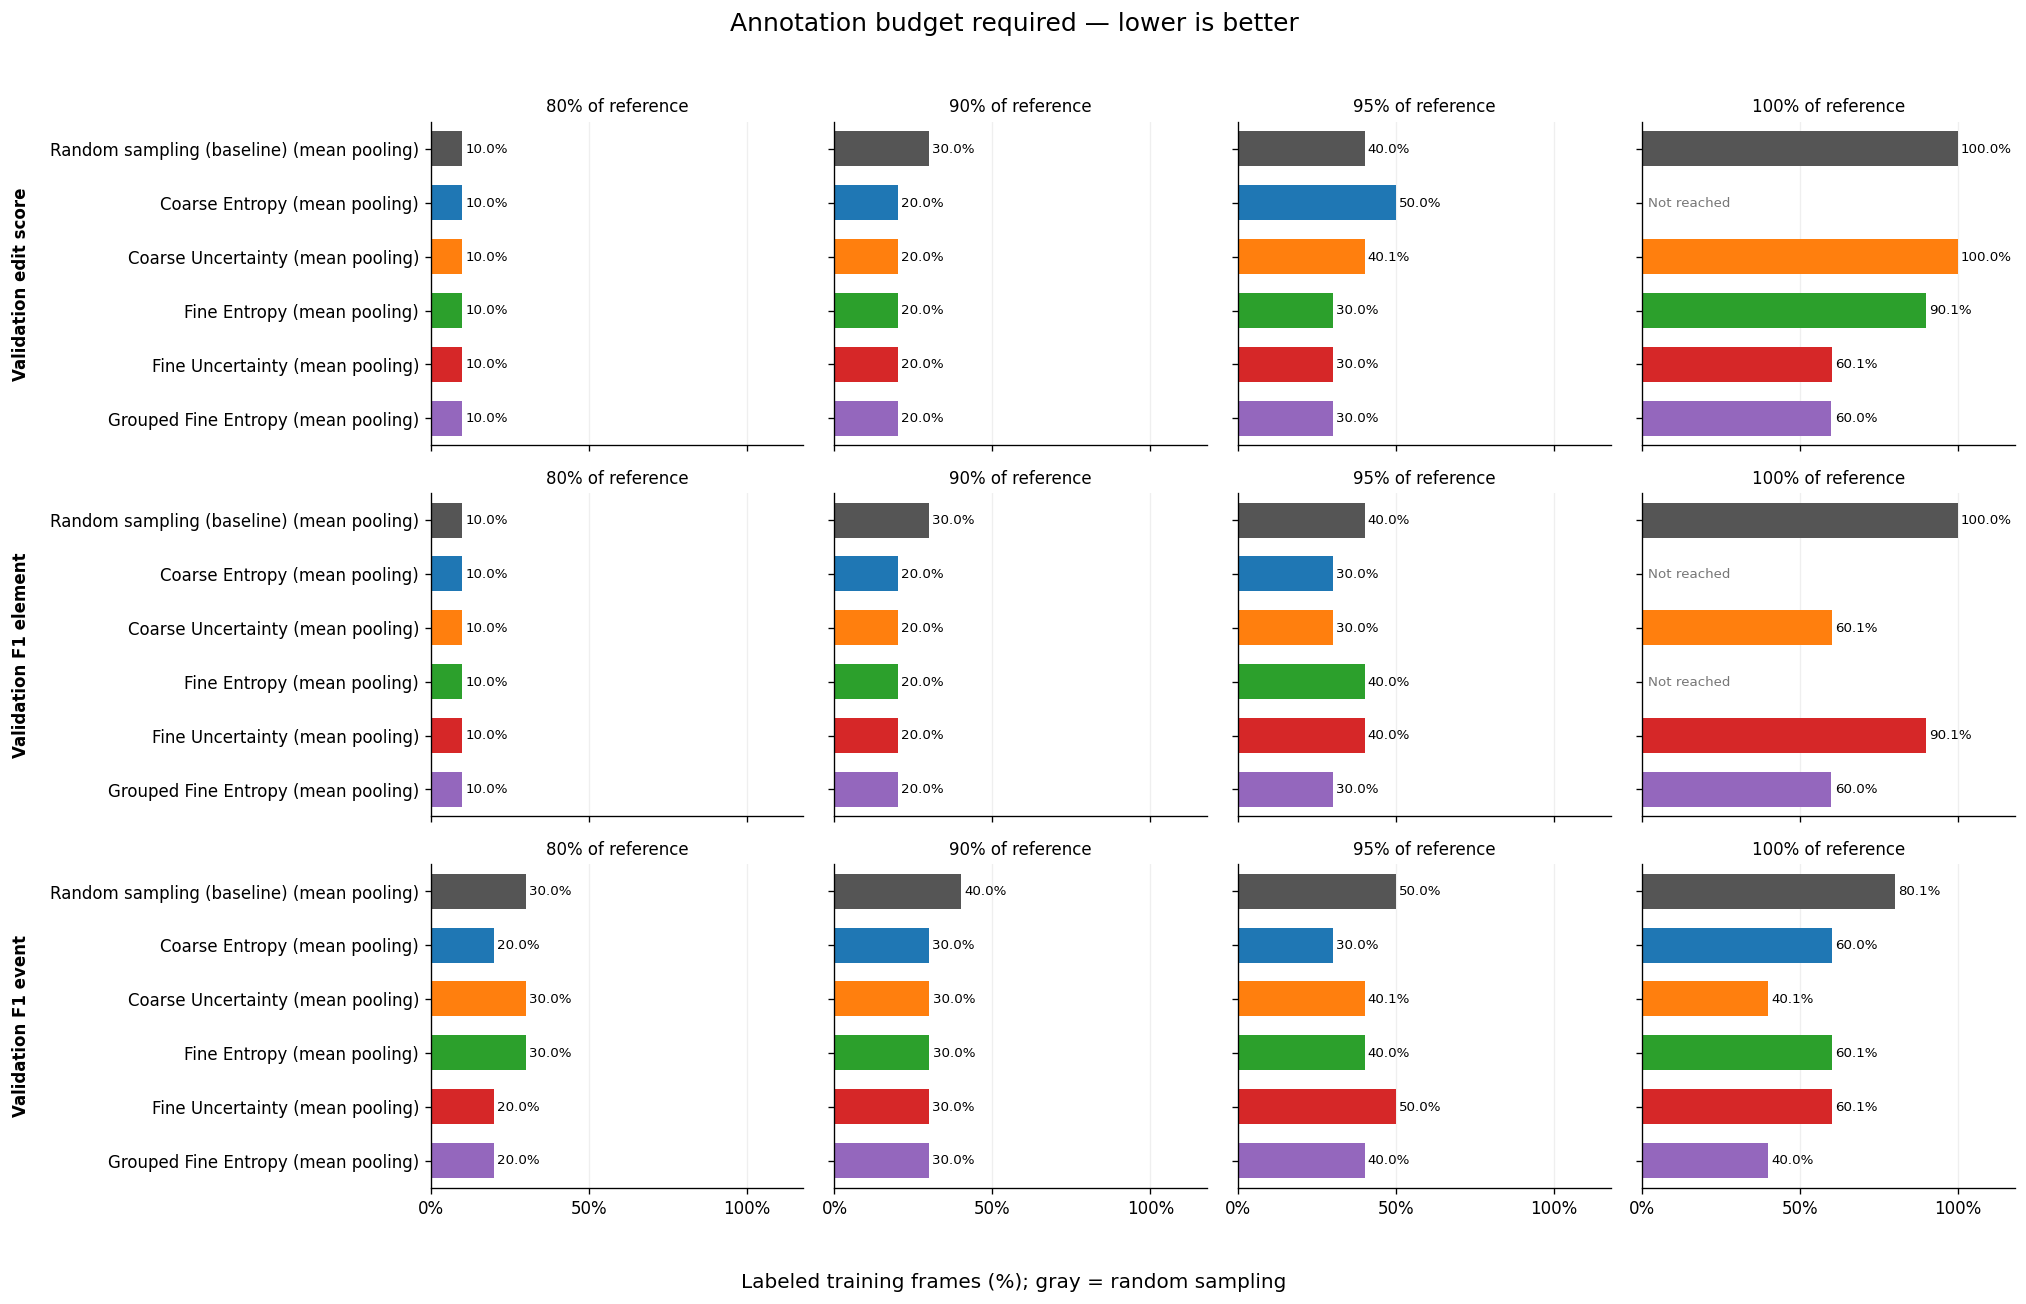

In [10]:
# Small multiples keep every table value visible without a dense legend.
fig, axes = plt.subplots(len(METRICS), len(TARGET_PCTS),
                         figsize=(17, 11), sharex=True, sharey=True, squeeze=False)
y = np.arange(len(group_order))
strategies = list(dict.fromkeys(
    settings_by_group[g]["query_strategy"] for g in group_order
    if settings_by_group[g]["query_strategy"] != "RANDOM_SAMPLING"
))
strategy_colors = {strategy: plt.get_cmap("tab10")(i)
                   for i, strategy in enumerate(strategies)}
strategy_colors["RANDOM_SAMPLING"] = (0.333, 0.333, 0.333, 1.0)
# Pooling variants of the same query strategy share a color across all panels.
colors = [strategy_colors[settings_by_group[g]["query_strategy"]] for g in group_order]
for row, metric in enumerate(METRICS.values()):
    for col, target in enumerate(TARGET_PCTS):
        ax = axes[row, col]
        values = budget_table[(metric, target)].to_numpy(dtype=float)
        available = np.isfinite(values)
        ax.barh(y[available], values[available],
                color=np.array(colors)[available], height=0.65)
        for position, value in zip(y, values):
            if np.isfinite(value):
                ax.text(value + 1, position, f"{value:.1f}%", va="center", fontsize=8)
            else:
                ax.text(2, position, "Not reached", va="center", fontsize=8, color="#777777")
        ax.set_title(f"{target}% of reference", fontsize=10)
        ax.set_xlim(0, 118)
        ax.set_xticks([0, 50, 100])
        ax.xaxis.set_major_formatter(PercentFormatter(100))
        ax.set_yticks(y, [labels[g] for g in group_order])
        ax.set_ylim(len(y) - 0.5, -0.5)
        ax.set_axisbelow(True)
        ax.grid(axis="x", alpha=0.2)
        if col == 0:
            ax.set_ylabel(metric, fontweight="bold", labelpad=12)
fig.suptitle("Annotation budget required — lower is better", fontsize=15)
fig.supxlabel("Labeled training frames (%); gray = random sampling")
fig.tight_layout(rect=(0, 0.025, 1, 0.96))
plt.show()


## Performance achieved at each annotation budget

Each point shows `100 × mean validation score / full-budget reference score` for one mean-pooling strategy. The reference is the same full-budget random-sampling mean used above; values above 100% indicate performance exceeding that reference.

The x-axis shows the **nominal acquisition budgets, 10%, 20%, …, 100%**, computed from the configured initial budget and acquisition batch size. Actual labeled-frame budgets can slightly exceed these nominal values because whole samples are acquired (see coverage above). Points use completed rounds and available-seed means, with no interpolation or extrapolation to fill missing rounds. Seed counts may vary, and lines only connect adjacent completed budget steps.

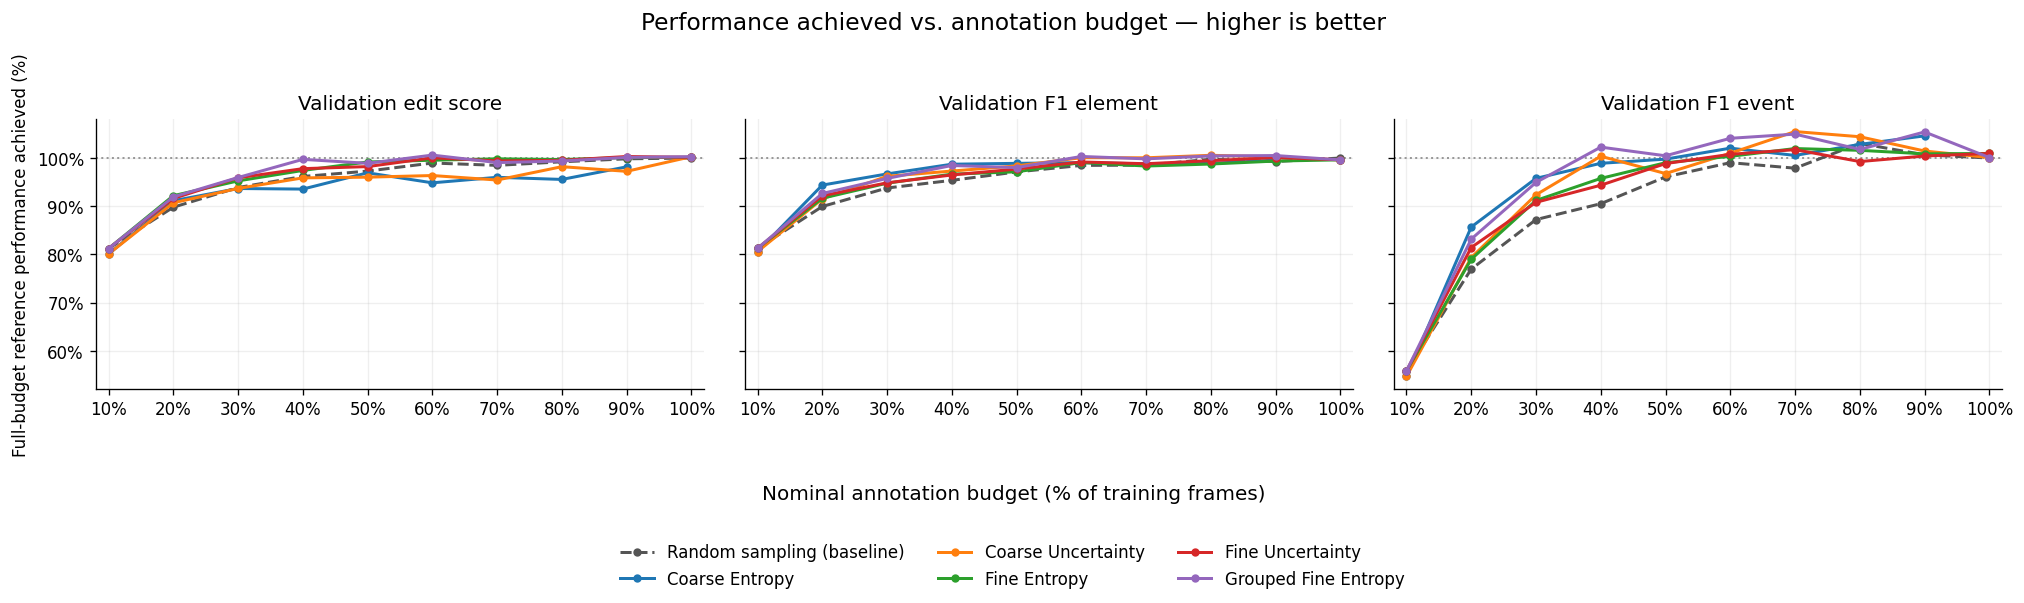

In [11]:
BUDGET_STEPS = np.arange(10, 101, 10)
relative_performance = summary.copy()
relative_performance["nominal_budget_pct"] = [
    min(settings_by_group[group]["initial_labeled_pool_size"]
        + round_number * settings_by_group[group]["query_batch_size"],
        settings_by_group[group]["max_annotation_budget"])
    for group, round_number in zip(relative_performance["group"], relative_performance["round"])
]
assert relative_performance["nominal_budget_pct"].isin(BUDGET_STEPS).all(), (
    "This graph expects acquisition rounds at 10% increments."
)
assert not relative_performance.duplicated(["group", "nominal_budget_pct"]).any()
for metric in METRICS:
    relative_performance[metric] = 100 * relative_performance[metric] / reference[metric]

fig, axes = plt.subplots(1, len(METRICS), figsize=(17, 5), sharex=True, sharey=True)
for ax, (metric, title) in zip(axes, METRICS.items()):
    ax.axhline(100, color="#999999", linestyle=":", linewidth=1.2)
    for group in group_order:
        strategy = settings_by_group[group]["query_strategy"]
        curve = relative_performance.loc[relative_performance["group"] == group].set_index(
            "nominal_budget_pct"
        ).reindex(BUDGET_STEPS)
        ax.plot(BUDGET_STEPS, curve[metric], color=strategy_colors[strategy],
                marker="o", markersize=4, linewidth=1.8,
                linestyle="--" if strategy == "RANDOM_SAMPLING" else "-",
                label=labels[group].replace(" (mean pooling)", ""))
    ax.set_title(title)
    ax.set_xticks(BUDGET_STEPS)
    ax.set_xlim(8, 102)
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Full-budget reference performance achieved (%)")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Performance achieved vs. annotation budget — higher is better", fontsize=14)
fig.supxlabel("Nominal annotation budget (% of training frames)", y=0.16)
fig.tight_layout(rect=(0, 0.21, 1, 0.94))
plt.show()
